# Parte 1
---

## Ejercicio 1

### Inciso 1
---

Acerca del dataset: **Telco Customer Churn**

En este dataset cada fila representa a un cliente, y cada columna hace referencia a un atributo del cliente. Hay informacion de 7043 clientes con 21 atributos cada uno.

Se tiene la siguiente información: clientes que se fueron en el ultimo mes (_churns_), servicios a los cuales se suscribieron los clientes, información de la cuenta de los clientes, e información demografica de cada uno (edad, género, etc).

El objetivo es **predecir el comportamiento de cada cliente** para poder retenerlos.

### Inciso 2
---

In [18]:
#   Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#   Para el estilo de los gráficos 
sns.set_theme(style="whitegrid")

#   Armar dataset
nombreDataset = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(nombreDataset)

In [19]:
#   Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Se puede ver que la columna ```TotalCharges``` aparece como _object_ (texto) cuando debería ser numérica. Esto se corrige en el Inciso 3.

In [20]:
#   Estadísticas descriptivas de las columnas numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


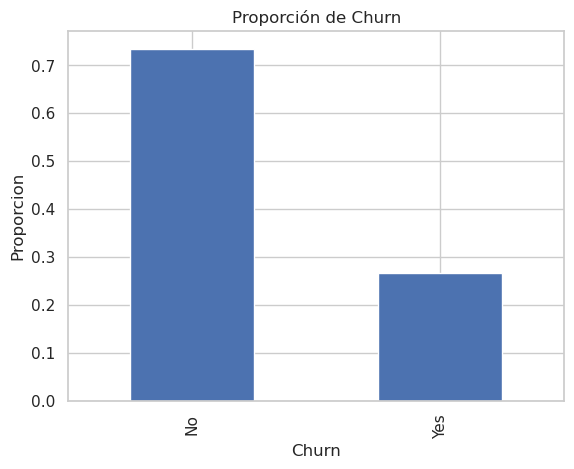

In [21]:
# 1 - Proporción de churn
df["Churn"].value_counts(normalize=True).plot(kind="bar", title="Proporción de Churn")
plt.ylabel("Proporcion")
plt.show()

El dataset esta desbalanceado: hay un 73% de clientes no son _churn_ y un 27% que sí. Esto va a ser relevante más adelante cuando elijamos métricas y estrategias de validación.

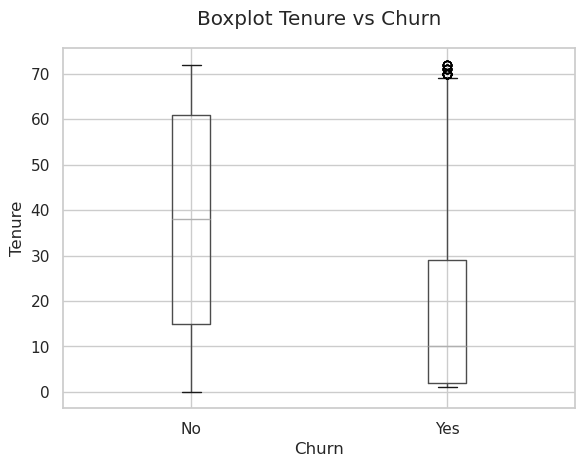

In [22]:
# 2 - Tenure vs Churn
df.boxplot(column="tenure", by="Churn")
plt.title("")
plt.suptitle("Boxplot Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

Los _churn_ suelen tener una antigüedad menor que los clientes que se quedan. Los clientes más nuevos son los más propensos a irse.

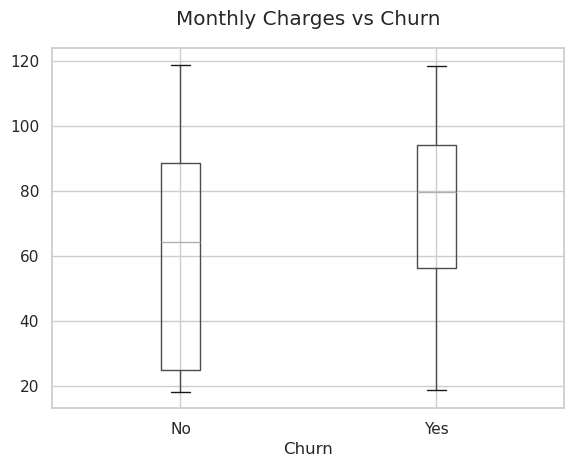

In [23]:
# 3 - MonthlyCharges vs Churn
df.boxplot(column="MonthlyCharges", by="Churn")
plt.suptitle("Monthly Charges vs Churn")
plt.title("")
plt.show()

Los _churn_ presentan cargos mensuales más altos en promedio que los que se quedan. La mediana de ```MonthlyCharges``` es mayor en el grupo de _churn_. Se podría decir que a mayor costo del servicio, la probabilidad de que un cliente se convierta en _churn_ es mayor.

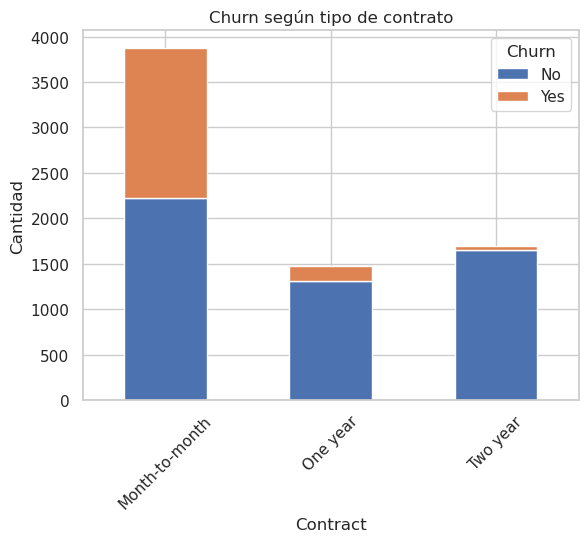

In [24]:
# 4 - Contract vs Churn
pd.crosstab(df["Contract"], df["Churn"]).plot(kind="bar", stacked=True)
plt.title("Churn según tipo de contrato")
plt.xlabel("Contract")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

Los _churn_ suelen tener contratos _month-to-month_, mientras que en los contratos de un año o dos los clientes tienden a quedarse.

### Inciso 3
---

Cuando se carga el dataset, algunas columnas que *deberían* ser numéricas pueden aparecer como tipo _object_. Esto pasa con la variable ```TotalCharges``` porque tiene valores que son _strings_ vacíos. Al encontrar ese valor no numérico, ```pandas``` interpreta toda la columna como texto.

Para solucionarlo, hay que reemplazar esos strings vacíos por ```NaN``` y convertir la columna a tipo numérico.

Si no se corrige este problema, la variable se puede ignorar o tratarse como categórica cuando en realidad es numérica. No se podria escalar ni imputar correctamente. Además, es una variable potencialmente relevante que no se estaría aprovechando.

In [25]:
#   Corrección de TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

#   Verificar que quedó OK
print("Tipo de TotalCharges:", df["TotalCharges"].dtype)
print("Valores nulos en TotalCharges:", df["TotalCharges"].isna().sum())

Tipo de TotalCharges: float64
Valores nulos en TotalCharges: 11


Se reemplazaron los strings vacíos por ```NaN``` y se convirtió la columna a tipo numérico. Los valores nulos resultantes se van a manejar con **imputación manual** en el Ejercicio 2.

## Ejercicio 2

### Inciso 1
---

Primero veamos *cuántos* valores faltantes hay en el dataset y en qué columnas están.

In [26]:
#   Cuántos valores faltantes hay?
nulos = df.isnull().sum()
nulos[nulos > 0]

TotalCharges    11
dtype: int64

Solamente ```TotalCharges``` tiene valores faltantes (los que venían como _strings_ vacíos y convertimos a ```NaN``` en el ejercicio anterior).

Para manejar estos valores faltantes vamos a usar las siguientes estrategias de imputación manual:

- En **variables numéricas**: imputar con la *mediana*, porque es robusta frente a valores extremos. A diferencia de la media, la mediana no se distorsiona si hay un par de valores muy altos o muy bajos.
- En **variables categóricas**: imputar con la *moda* (el valor más frecuente), porque no tiene sentido calcular un promedio de texto.

Estas imputaciones se van a implementar dentro de un _pipeline_ de ```sklearn``` para evitar _Data Leakage_. Dentro del _pipeline_, se usa ```SimpleImputer```: el objeto de ```sklearn``` que se encarga de rellenar los ```NaN```.

In [27]:
from sklearn.impute import SimpleImputer

#   Imputador para numéricas: rellena NaN con la mediana de la columna
imputer_num = SimpleImputer(strategy="median")

#   Imputador para categóricas: rellena NaN con el valor mas frecuente
imputer_cat = SimpleImputer(strategy="most_frequent")

#   Estos objetos todavia no se ejecutan, solo se definen.
#   Se van a usar dentro del pipeline más adelante para que el fit
#       se haga solo con datos de entrenamiento y se evite data leakage.
print("Imputador numérico:", imputer_num)
print("Imputador categórico:", imputer_cat)

Imputador numérico: SimpleImputer(strategy='median')
Imputador categórico: SimpleImputer(strategy='most_frequent')


### Inciso 2
---

Las **variables categóricas** son las que tienen texto en vez de números. Los modelos de _machine learning_ no pueden trabajar con texto directamente, necesitan números sí o sí. Para convertirlas vamos a usar **One-Hot Encoding**, que crea una columna binaria (0 o 1) por cada categoría posible. Se usa ```drop_first=True``` para eliminar una de las columnas y evitar redundancia: si todas las demás columnas son 0, ya se sabe que pertenece a la categoría eliminada.

Las **variables numéricas** se van a **escalar** con ```StandardScaler```, que transforma cada columna para que tenga media 0 y desvío estandar 1. Esto es necesario para modelos como la Regresion Logística, que usan gradiente descendiente para entrenarse. Si las variables tienen escalas muy distintas, el gradiente se mueve de forma alocada y el entrenamiento es ineficiente.

In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#   Separar features y variable objetivo
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["Churn", "customerID"])

#   Identificar columnas numéricas y categóricas
numericas = X.select_dtypes(include=["int64", "float64"]).columns
categoricas = X.select_dtypes(include=["object"]).columns

print("Numéricas:", list(numericas))
print("Categóricas:", list(categoricas))

Numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [29]:
#   Definir el preprocesamiento con ColumnTransformer
#   Esto solo DEFINE las transformaciones, no las ejecuta todavía

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numericas),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), categoricas)
])

print("Preprocessor definido")

Preprocessor definido


```ColumnTransformer``` aplica transformaciones distintas a columnas distintas. A las numéricas les aplica imputacion con mediana y luego escalado. A las **categóricas** les aplica _imputación con moda_ y luego _One-Hot Encoding_.

Todavía no se ejecutó nada, sino que se definió la estrategia de preprocesamiento. La ejecución se hace en el Ejercicio 3 dentro de un pipeline, después de hacer el train/test split, para evitar _data leakage_.

### Inciso 3
---

La división entre **datos de entrenamiento** y **test** debe realizarse _antes_ de la imputación y del escalado. Luego tanto la imputación como el escalado se ajustan únicamente con los datos de entrenamiento. Después, esas transformaciones ya aprendidas se aplican tanto sobre entrenamiento como sobre test.

Las técnicas como la imputación y el escalado calculan estadísticos a partir de los datos. Si se hicieran _antes_ del train/test _split_, estaríamos usando información del conjunto de test para preparar los datos de entrenamiento.

El problema que aparece se conoce como **data leakage**: el modelo estaría entrenando con información que en la práctica _no debería_ conocer. Cuando el modelo este en producción no va a tener acceso a datos futuros. Este fenómeno produce una evaluación _artificialmente optimista_ y _poco realista_ sobre su verdadero desempeño en datos no vistos.

El **orden correcto** es:
1. Separar ```X``` e ```y```.
2. Hacer el _split_.
3. Ajustar la imputación y el escalado solo con ```X_train```.
4. Aplicar sobre ```X_train``` y ```X_test```.

Para implementar esto de forma limpia usamos un _pipeline_ de ```sklearn``` que encadena los pasos de preprocesamiento con el modelo. El _pipeline_ se encarga automáticamente de ajustar sólo con los datos de entrenamiento en cada paso, incluyendo dentro de la validación cruzada.

Por eso el _preprocessor_ que definimos en el Inciso 2 no se ejecutó todavia. El ajuste se va a hacer recién en el Ejercicio 3, después del _split_.

## Ejercicio 3

### Inciso 1
---

In [30]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

#   Train/Test split (ANTES de cualquier preprocesamiento)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"Proporción churn en train: {y_train.mean():.2%}")
print(f"Proporción churn en test: {y_test.mean():.2%}")

Train: 5634 muestras
Test: 1409 muestras
Proporción churn en train: 26.54%
Proporción churn en test: 26.54%


Se puede verificar que ```stratify=y``` mantuvo la misma proporción de _churn_ en ambos conjuntos (aproximadamente 27% en los dos).

In [31]:
#   Pipeline completo: preprocesamiento + modelo
#   Acá se usa el preprocessor que definimos en el Ejercicio 2
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

#   Validación cruzada estratificada con K=5
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X_train, y_train, cv=skf, scoring="accuracy")

print("Scores por fold:", scores)
print(f"Accuracy promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")

Scores por fold: [0.79946761 0.78172138 0.80212955 0.81721384 0.81261101]
Accuracy promedio: 0.8026 (+/- 0.0123)


El _pipeline_ encadena el preprocesamiento (imputación + escalado + _encoding_) con el modelo (Regresion Logistica). Cuando ```cross_val_score``` ejecuta la validación cruzada, en cada _fold_ el _pipeline_ hace _fit_ del preprocesamiento solo con los 4 folds de entrenamiento y _transform_ sobre el _fold_ de validación. Esto previene _data leakage_ automáticamente.

### Inciso 2
---

Una partición _Holdout_ divide los datos **una sola vez** en entrenamiento y validación. Eso hace que la evaluación dependa mucho de como haya quedado esa única división. Si por mala fortuna los datos mas difíciles caen todos en validación, la evaluación va a ser pesimista, y viceversa.

En cambio, con _K-Fold Cross-Validation_ el conjunto de entrenamiento se divide en 5 partes (_folds_) y el modelo se entrena y evalúa 5 veces, usando cada parte como validación una vez. Luego se promedian los resultados.

Esto da una estimación mas robusta del desempeño porque *reduce la dependencia de una sola partición*, aprovecha mejor los datos disponibles y disminuye la varianza de la evaluacion.

En este caso, sí es conveniente usar _StratifiedKFold_ porque mantiene en cada _fold_ una proporción de clases similar a la del dataset original. Como la variable ```Churn``` está desbalanceada (73% No vs 27% Si), un _K-Fold_ normal podría generar un _fold_ con, por ejemplo, 85% de "No Churn" por azar, lo cual no sería representativo. _Stratified K-Fold_ garantiza que cada fold tenga aproximadamente la *misma distribución* de clases.

## Ejercicio 4

### Inciso 1
---

In [ ]:
#   Entrenar modelo final sobre todo el conjunto de entrenamiento
model.fit(X_train, y_train)

#   Predicciones sobre el conjunto de test
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))

Accuracy: 0.8055
Precision: 0.6572
Recall: 0.5588
F1-score: 0.604


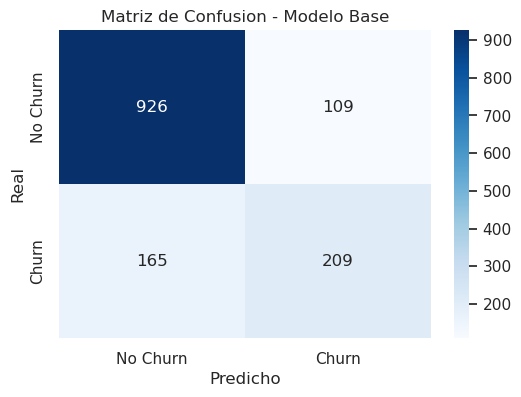

In [ ]:
#   Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.title("Matriz de Confusión - Modelo Base")
plt.show()

### Inciso 2
---

El _accuracy_ no es una buena métrica en este problema porque la variable objetivo está desbalanceada. La mayoría de los clientes no abandona el servicio, entonces un modelo puede obtener un _accuracy_ alto simplemente prediciendo siempre la clase mayoritaria, sin haber aprendido ningún patron útil.

In [ ]:
#   Modelo naive: siempre predice la clase mayoritaria (No Churn = 0)
y_naive = [0] * len(y_test)

acc_naive = accuracy_score(y_test, y_naive)
print(f"Accuracy del modelo naive: {acc_naive:.4f}")

Un modelo naive que siempre predice "No Churn" obtiene un _accuracy_ de aproximadamente 73%, sin haber aprendido nada. Si nuestro modelo tiene un 80% de accuracy, la mejora real respecto a no hacer nada es de solo 7 puntos porcentuales.

El _accuracy_ esconde si el modelo esta detectando bien a los _churn_, que es lo que realmente importa para el negocio. Por eso, son necesarias métricas como _Precision_, _Recall_ y _F1-Score_ que miran específicamente el rendimiento sobre la clase _churn_.

## Ejercicio 5

### Inciso 1
---

Para lidiar con el desbalanceo de clases vamos a usar _SMOTE (Synthetic Minority Oversampling Technique)_, una técnica de _oversampling_ que *genera ejemplos sintéticos de la clase minoritaria* interpolando entre muestras existentes. Se aplica solo sobre el conjunto de entrenamiento, nunca sobre test.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import classification_report

#   Pipeline con preprocesamiento + SMOTE + modelo
#   Se usa ImbPipeline en vez del Pipeline de sklearn porque
#       el de sklearn no soporta pasos de resampling como SMOTE.
#   ImbPipeline sabe que SMOTE solo se aplica durante fit, nunca durante predict.
model_balanceado = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Entrenar y evaluar
model_balanceado.fit(X_train, y_train)
y_pred_balanceado = model_balanceado.predict(X_test)

print(classification_report(y_test, y_pred_balanceado))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



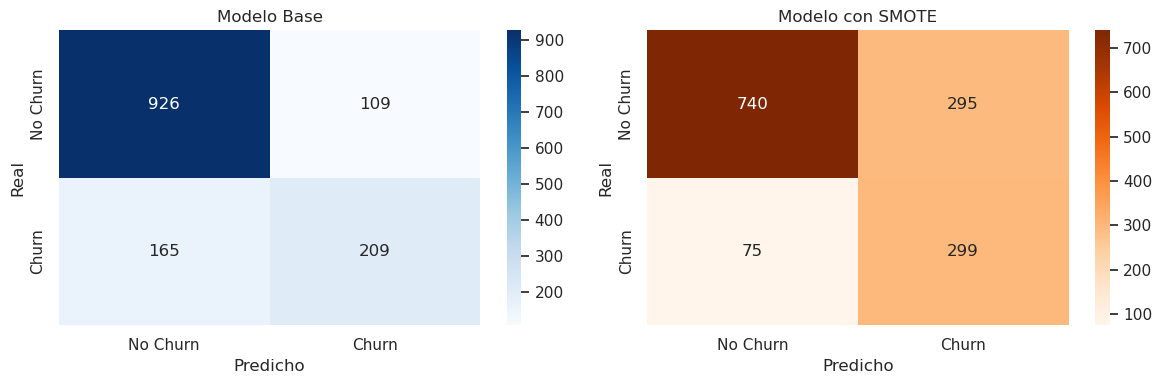

In [ ]:
#   Comparación de matrices de confusión
matriz_bal = confusion_matrix(y_test, y_pred_balanceado)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], ax=axes[0])
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")
axes[0].set_title("Modelo Base")

sns.heatmap(matriz_bal, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"], ax=axes[1])
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")
axes[1].set_title("Modelo con SMOTE")

plt.tight_layout()
plt.show()

In [37]:
#   Comparación numérica de métricas
print("--- Modelo Base ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print()
print("--- Modelo con SMOTE ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_balanceado):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_balanceado):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_balanceado):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_balanceado):.4f}")

--- Modelo Base ---
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-score:  0.6040

--- Modelo con SMOTE ---
Accuracy:  0.7374
Precision: 0.5034
Recall:    0.7995
F1-score:  0.6178


Con _SMOTE_ el _Recall_ sube (se detectan más _churn_ reales) pero _Precision_ baja un poco porque hay más falsos positivos. Esto es el _tradeoff_ esperado: al balancear las clases, el modelo arriesga más y predice más _churn_ en general.

### Inciso 2
---

Suponiendo que el equipo de marketing va a ofrecer un descuento del 50% por 3 meses a los clientes que el modelo prediga como _churn_:

1) Un **falso positivo (FP)** significa que le estamos ofreciendo un descuento a un cliente que no tenia intención de irse. Esto es un costo adicional innecesario para la empresa: se le regala un 50% de descuento durante 3 meses a alguien que se iba a quedar de todas formas.

2) Un **falso negativo (FN)** significa que no estamos detectando a un cliente que va a ser _churn_. La empresa pierde la oportunidad de retenerlo y pierde todos los ingresos futuros de ese cliente.

3) Si el descuento es muy costoso para la empresa, cada falso positivo duele mucho económicamente. En ese caso conviene maximizar _Precision_ para asegurarnos de que cuando el modelo diga que un cliente es _churn_, sea muy probable que *realmente* se vaya. Se minimizan los falsos positivos.

Si el descuento fuera casi gratuito, los falsos positivos no cuestan casi nada. En ese caso conviene maximizar el _Recall_ para detectar la mayor cantidad posible de clientes en riesgo. Se aceptan más falsos positivos si esto permite reducir los falsos negativos y evitar la pérdida de clientes.

Mirando las matrices de confusión: el modelo con _SMOTE_ tiene mas _Recall_ (detecta mas _churn_) pero también mas falsos positivos. Si el descuento es barato se prefiere este modelo. Si el descuento es caro se prefiere el modelo base que tiene mejor _Precision_.

# Parte 2: Reformulando el Problema
---

En esta sección vamos a usar el mismo dataset pero para predecir algo distinto a ```Churn```.

Elegimos como nuevo _target_ la variable ```MonthlyCharges```, que es numérica. Como la consigna pide *clasificación binaria*, la vamos a convertir a dos categorías: clientes que pagan por encima de la mediana (**gasto alto**) y clientes que pagan por debajo (**gasto bajo**).

Usamos la mediana como punto de corte porque divide al dataset en dos mitades iguales, lo cual nos da un problema balanceado. Además, tiene sentido desde el negocio: entender qué características hacen que un cliente termine pagando más puede servir para diseñar ofertas o detectar oportunidades de _upselling_.

Mediana de MonthlyCharges: 70.35
Media de MonthlyCharges: 64.76


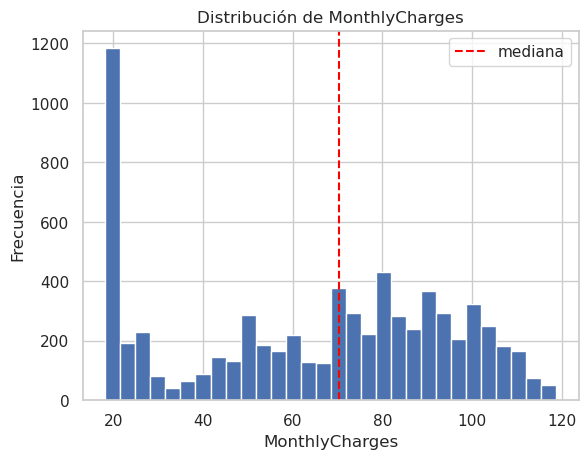

In [38]:
#   Ver la distribución de MonthlyCharges
print("Mediana de MonthlyCharges:", df["MonthlyCharges"].median())
print("Media de MonthlyCharges:", round(df["MonthlyCharges"].mean(), 2))

df["MonthlyCharges"].hist(bins=30)
plt.axvline(df["MonthlyCharges"].median(), color="red", linestyle="--", label="mediana")
plt.title("Distribución de MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [39]:
#   Crear el nuevo target binario
mediana = df["MonthlyCharges"].median()
y2 = (df["MonthlyCharges"] > mediana).astype(int)

print("Distribución del nuevo target:")
print(y2.value_counts(normalize=True))

Distribución del nuevo target:
MonthlyCharges
0    0.500923
1    0.499077
Name: proportion, dtype: float64


El nuevo _target_ queda balanceado (aprox 50/50). Los que pagan más que la mediana son clase ```1``` (**gasto alto**) y los que pagan menos son clase ```0``` (**gasto bajo**).

In [40]:
#   Sacar MonthlyCharges de los features porque es el target
#   También sacamos Churn y customerID como antes
X2 = df.drop(columns=["Churn", "customerID", "MonthlyCharges"])

# split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

print(f"Train: {X2_train.shape[0]} muestras")
print(f"Test: {X2_test.shape[0]} muestras")

Train: 5634 muestras
Test: 1409 muestras


In [41]:
#   Identificar columnas
num2 = X2_train.select_dtypes(include=["int64", "float64"]).columns
cat2 = X2_train.select_dtypes(include=["object"]).columns

#   Armar preprocessor nuevo (mismo esquema que antes)
preprocessor2 = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num2),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), cat2)
])

#   Pipeline con regresión logística
model2 = Pipeline([
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [43]:
# Entrenar y predecir
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

# Métricas
print("Accuracy:", round(accuracy_score(y2_test, y2_pred), 4))
print("Precision:", round(precision_score(y2_test, y2_pred), 4))
print("Recall:", round(recall_score(y2_test, y2_pred), 4))
print("F1-Score:", round(f1_score(y2_test, y2_pred), 4))

Accuracy: 0.9801
Precision: 0.9884
Recall: 0.9716
F1-Score: 0.9799


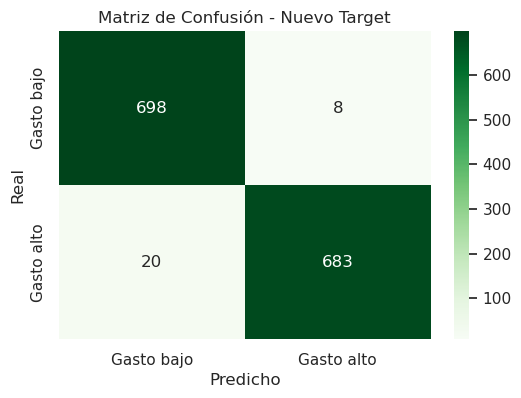

In [44]:
#   Matriz de confusion
mat2 = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(mat2, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Gasto bajo", "Gasto alto"],
            yticklabels=["Gasto bajo", "Gasto alto"])
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.title("Matriz de Confusión - Nuevo Target")
plt.show()

El modelo da métricas bastante altas para este nuevo problema. Esto tiene sentido: hay variables en el dataset que están *muy relacionadas* con cuánto paga un cliente por mes. Por ejemplo, los servicios que tiene contratados (internet, fibra óptica, streaming, etc) influyen directamente en el cargo mensual. Entonces el modelo puede "aprender" esa relación sin mucha dificultad.

A diferencia del problema de ```Churn``` donde el modelo tenía alrededor de 80% de _Accuracy_, acá esa métrica aumenta muchísimo más. Esto muestra que no todos los problemas predictivos son igual de difíciles: algunos _targets_ son mas fáciles de predecir que otros, dependiendo de qué tan fuerte es la relación con los _features_ disponibles.

Además, como el _target_ esta balanceado (50/50), acá sí tiene sentido mirar a _Accuracy_ como métrica principal, a diferencia del problema de ```Churn``` donde estaba desbalanceado.

# Conclusiones
---

A lo largo de este trabajo se recorrió el ciclo completo de un problema de _machine learning_, desde la exploración de los datos hasta la evaluación final del modelo.

Los principales hallazgos fueron:

- **Atención al balance**. El dataset ```Telco Customer Churn``` tiene un desbalanceo importante que afecta tanto la elección de métricas como la estrategia de entrenamiento.

- **La limpieza de datos es fundamental**. La columna ```TotalCharges``` venía como texto por tener _strings_ vacíos, lo cual habría causado problemas si no se detectaba a tiempo.

- **El orden de las operaciones importa**. Imputar o escalar datos antes del train/test _split_ introduce _data leakage_, lo cual hace que las métricas sean artificialmente optimistas. Usar un _pipeline_ de ```sklearn``` resuelve esto automáticamente.

- **Accuracy nos puede engañar**. Un modelo que siempre predice _No Churn_ ya tiene 73% de _Accuracy_ sin haber aprendido nada. Métricas como _Precision_, _Recall_ y _F1-Score_ son más relevantes en estos casos.

- **Uso de SMOTE**. _SMOTE_ mejora el _Recall_ del modelo a costa de bajar un poco _Precision_. La elección entre ambos modelos depende del contexto de negocio: si el descuento de retención es caro se prefiere _Precision_ alta, si es barato se prefiere _Recall_ alto.

- En la Parte 2, el problema de predecir si un cliente es de gasto alto o bajo resultó mucho más fácil que predecir ```Churn```, lo cual muestra que la dificultad de un problema depende de qué tan fuerte es la relación entre los _features_ y el _target_.

Posibles mejoras para iteraciones futuras:

- Probar otros modelos como _Random Forest_ o _Gradient Boosting_ que podrían capturar relaciones no lineales que la Regresión Logística no puede.

- Hacer ingeniería de atributos. Crear variables nuevas como el _ratio_ entre ```MonthlyCharges``` y ```tenure```, o agrupar servicios similares.

- Ajustar el _threshold_ de clasificación en vez de usar el default de 0,5. Moviendo el _threshold_, se puede controlar directamente el _tradeoff_ entre _Precision_ y _Recall_.

- Usar la curva ROC y el AUC-ROC para comparar modelos de forma más completa, sin depender de un _threshold_ fijo.